In [215]:
import numpy as np # linear algebra
import pandas as pd # data processing
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import lightgbm as lgb
import xgboost as xgb


In [216]:
products = pd.read_csv("/content/drive/MyDrive/Buynomics Gabriel Galindo/product.csv")
sales = pd.read_csv("/content/drive/MyDrive/Buynomics Gabriel Galindo/sales.csv")

--------------------------
# 1. Familiarise with data:

In [217]:
products.head()


,Unnamed: 0,brand,flavour,volume_per_joghurt_g,packsize,product_id
0,0,Mueller,blueberry,150,6,0
1,1,Oikos,chocolate,1000,1,1
2,2,Alnatura,strawberry,1000,1,2
3,3,Mueller,straciatella,500,6,3
4,4,Danone,straciatella,150,6,4


In [218]:
sales.head()

,Unnamed: 0,date,product_id,price,units
0,0,2020-01-01,0,4.65,1126.0
1,1,2020-01-02,0,4.76,1205.0
2,2,2020-01-03,0,5.22,1007.0
3,3,2020-01-04,0,5.45,1282.0
4,4,2020-01-05,0,3.33,1037.0


In [219]:
products=products.drop("Unnamed: 0", axis=1)
sales=sales.drop("Unnamed: 0", axis=1)

--------------------------

# 2. Visualizations:

In [224]:
final_df = sales.merge(products, on='product_id', how='left')
final_df['date'] = pd.to_datetime(final_df['date'])
final_df.head()

,date,product_id,price,units,brand,flavour,volume_per_joghurt_g,packsize
0,2020-01-01,0,4.65,1126.0,Mueller,blueberry,150,6
1,2020-01-02,0,4.76,1205.0,Mueller,blueberry,150,6
2,2020-01-03,0,5.22,1007.0,Mueller,blueberry,150,6
3,2020-01-04,0,5.45,1282.0,Mueller,blueberry,150,6
4,2020-01-05,0,3.33,1037.0,Mueller,blueberry,150,6


In [ ]:
# Add some representative metrics
final_df['Avg_Unit_by_Product'] = final_df.groupby('product_id')['units'].transform('mean')
final_df['Avg_Price_by_Brand'] = final_df.groupby('brand')['price'].transform('mean')
final_df['Avg_Price_by_Product'] = final_df.groupby('product_id')['price'].transform('mean')
final_df['Total_volum_pack'] = final_df['volume_per_joghurt_g'] * final_df['packsize']

display(final_df)

,date,product_id,price,units,brand,flavour,volume_per_joghurt_g,packsize,Avg_Unit_by_Product,Avg_Price_by_Brand,Avg_Price_by_Product,Total_volum_pack
0,2020-01-01,0,4.65,1126.0,Mueller,blueberry,150,6,1270.1,5.59125,4.602,900
1,2020-01-02,0,4.76,1205.0,Mueller,blueberry,150,6,1270.1,5.59125,4.602,900
2,2020-01-03,0,5.22,1007.0,Mueller,blueberry,150,6,1270.1,5.59125,4.602,900
3,2020-01-04,0,5.45,1282.0,Mueller,blueberry,150,6,1270.1,5.59125,4.602,900
4,2020-01-05,0,3.33,1037.0,Mueller,blueberry,150,6,1270.1,5.59125,4.602,900
...,...,...,...,...,...,...,...,...,...,...,...,...
255,2020-01-06,26,3.18,1524.0,Oikos,strawberry,500,1,1362.1,4.21825,3.327,500
256,2020-01-07,26,2.81,1153.0,Oikos,strawberry,500,1,1362.1,4.21825,3.327,500
257,2020-01-08,26,5.00,913.0,Oikos,strawberry,500,1,1362.1,4.21825,3.327,500
258,2020-01-09,26,3.38,1603.0,Oikos,strawberry,500,1,1362.1,4.21825,3.327,500


In [226]:
num_cols =  final_df.select_dtypes(include="number").columns.tolist()
cat_cols = ['brand', 'flavour']

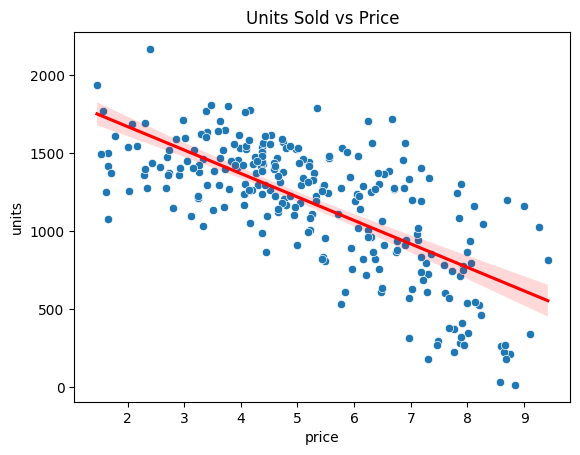

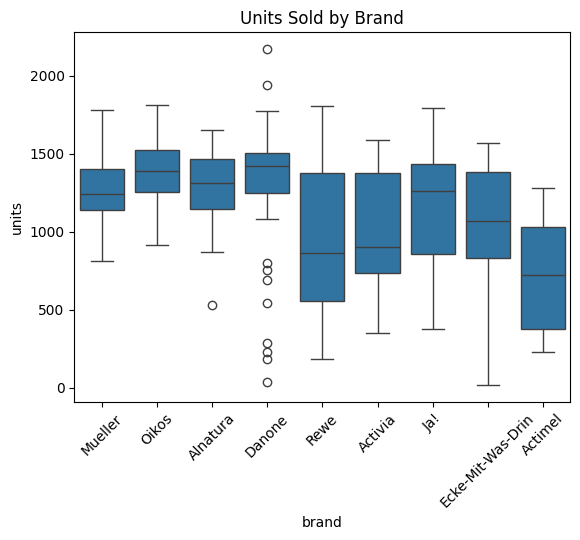

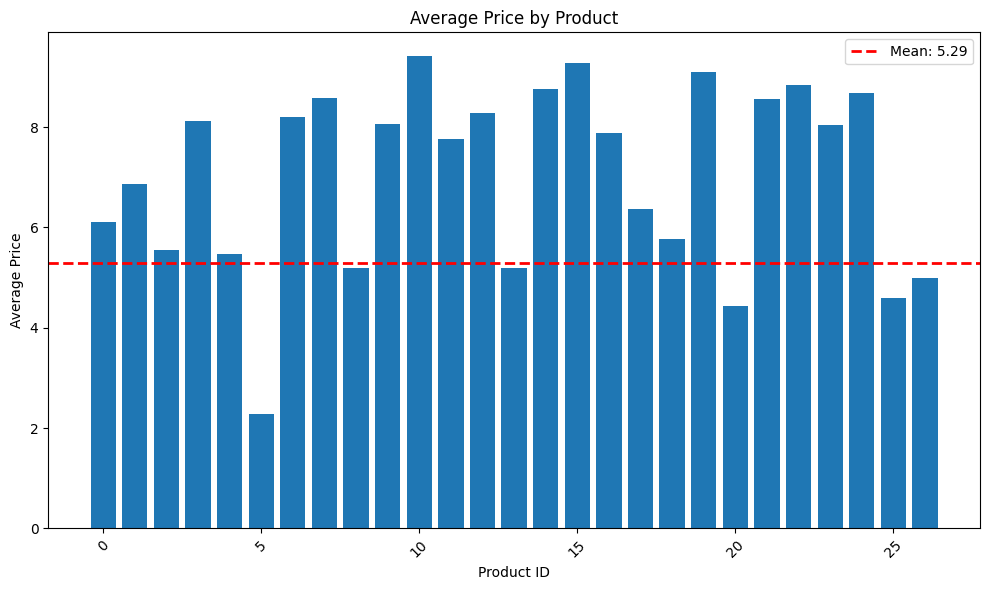

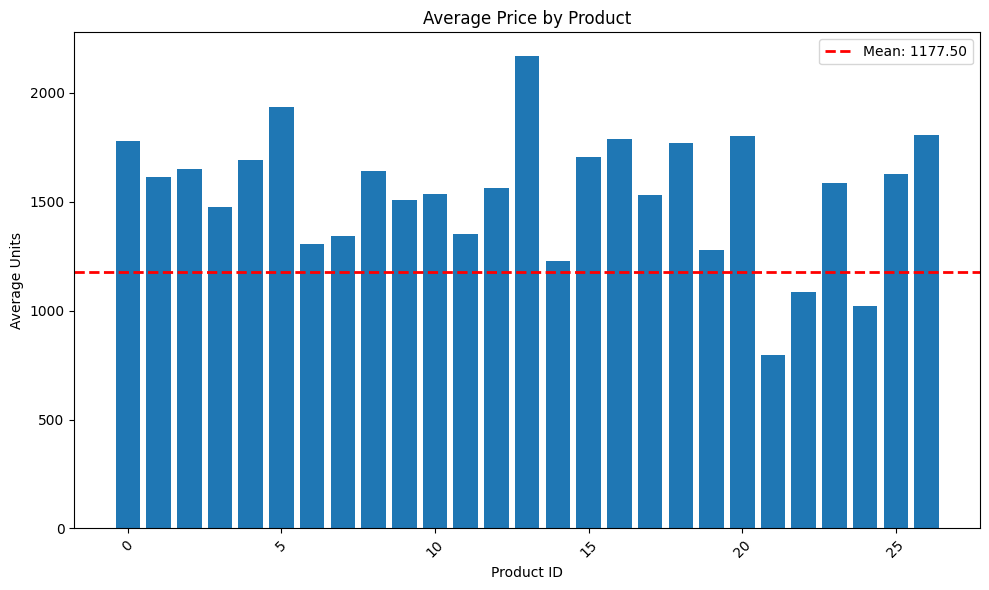

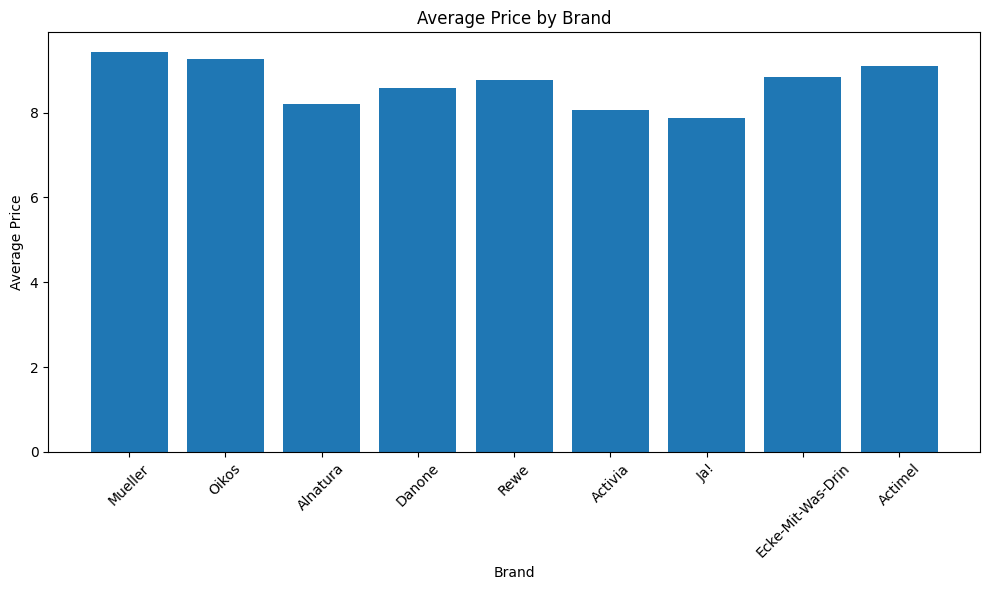

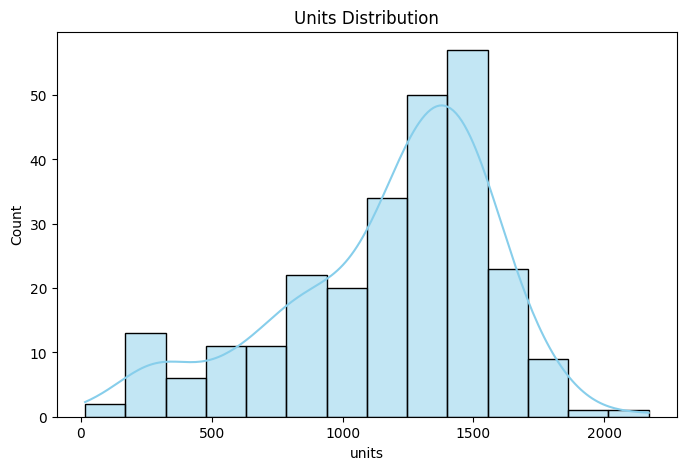

In [ ]:
sns.scatterplot(data=final_df, x='price', y='units')
sns.regplot(data=final_df, x='price', y='units', scatter=False, color='red')
plt.title('Units Sold vs Price')
plt.show()

sns.boxplot(data=final_df, x='brand', y='units')
plt.title('Units Sold by Brand')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(final_df['product_id'], final_df['price'])
overall_mean = final_df['price'].mean()
plt.axhline(y=overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mean:.2f}')
plt.title('Average Price by Product')
plt.xlabel('Product ID')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.legend()  # show the legend for the mean line
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(final_df['product_id'], final_df['units'])
overall_mean = final_df['units'].mean()
plt.axhline(y=overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {overall_mean:.2f}')
plt.title('Average Price by Product')
plt.xlabel('Product ID')
plt.ylabel('Average Units')
plt.xticks(rotation=45)
plt.legend()  # show the legend for the mean line
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(final_df['brand'], final_df['price'])
plt.title('Average Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# SalePrice distribution
plt.figure(figsize = (8,5))
sns.histplot(final_df['units'], kde = True, color = "skyblue")
plt.title("Units Distribution")
plt.show()

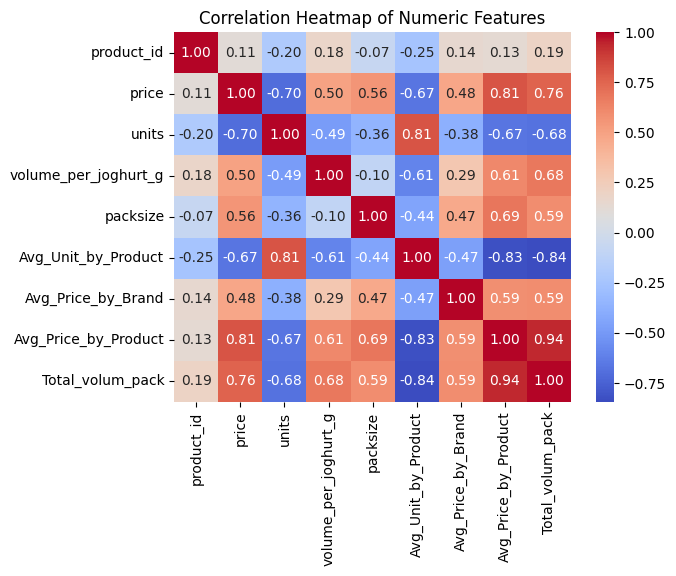

In [228]:
num_cols = final_df.select_dtypes(include = "number").columns
plt.figure()
sns.heatmap(final_df[num_cols].corr(), annot = True, fmt = ".2f", cmap = "coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()
